# 03 EDA: Feature Understanding

본 단계에서는 교통사고 데이터와 구축된 설명 변수들의 기본 분포를 분석하여  
도시 구조와 교통사고 발생 간의 관계를 탐색한다.

EDA의 목적은 다음과 같다.

1. 교통사고 발생 분포 확인
2. 주요 도시 활동 변수들의 분포 이해
3. 변수 간 관계 및 상관 구조 파악
4. 사고 다발 격자의 특징 탐색

이 분석 결과는 이후 공간 분석 및 리스크 모델링의 근거로 활용된다.

In [1]:
# 필요한 라이브러리 불러오기

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
sns.set_theme(
    style="whitegrid",
    palette="deep",
    context="notebook",
    font_scale=1.2
)

plt.rcParams["figure.figsize"] = (10, 6)
mpl.rcParams["axes.unicode_minus"] = False

In [2]:
sns.set_style("whitegrid")
train = pd.read_csv("../outputs/processed/02_train_base_final_features.csv")
train.head()

,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,daycare_count,cctv_count,speedbump_count,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사581304,경기도 성남시,POLYGON ((127.02677465735422 37.37172194466841...,0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
1,다사581305,경기도 성남시,POLYGON ((127.02676899519032 37.37262330005522...,0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
2,다사581306,경기도 성남시,POLYGON ((127.02676333277432 37.37352465530359...,0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
3,다사582304,경기도 성남시,POLYGON ((127.02790403835982 37.37172645813172...,0,0,0.0,0.022768,0.018269,0.004499,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
4,다사582305,경기도 성남시,POLYGON ((127.02789838970781 37.37262781366482...,0,0,0.0,0.031655,0.016485,0.015169,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0


In [3]:
# 데이터 구조 확인
train.shape
train.columns
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105032 entries, 0 to 105031
Data columns (total 28 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   gid              105032 non-null  object 
 1   city             105032 non-null  object 
 2   geometry         105032 non-null  object 
 3   acc_cnt          105032 non-null  int64  
 4   acc_binary       105032 non-null  int64  
 5   resident_pop     105032 non-null  float64
 6   flow_pop         105032 non-null  float64
 7   working_pop      105032 non-null  float64
 8   visit_pop        105032 non-null  float64
 9   service_pop      105032 non-null  float64
 10  mean_speed       105032 non-null  float64
 11  traffic_volume   105032 non-null  float64
 12  congestion_freq  105032 non-null  float64
 13  congestion_time  105032 non-null  float64
 14  crosswalk_count  105032 non-null  float64
 15  bus_stop_count   105032 non-null  float64
 16  school_count     105032 non-null  floa

,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,mean_speed,traffic_volume,congestion_freq,...,school_count,kinder_count,daycare_count,cctv_count,speedbump_count,is_residential,is_commercial,is_green,is_road,is_public
count,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,...,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000,105032.000000
mean,0.135797,0.069579,7.132262,2.145186,0.651708,1.493478,0.177297,11.689898,149.340756,15.581925,...,0.005170,0.004599,0.026535,0.023412,0.048138,0.046138,0.007826,0.023307,0.029886,0.004056
std,0.701094,0.254437,33.748294,8.965841,3.014874,6.330743,0.747643,20.788614,397.591251,28.757228,...,0.076221,0.068357,0.193659,0.235548,0.423400,0.209786,0.088119,0.150878,0.170274,0.063557
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.032406,0.001067,0.005020,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.185610,0.075848,0.105161,0.015191,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.861210,0.294977,0.536671,0.069383,21.718932,134.729167,15.440000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,24.000000,1.000000,1317.254606,332.106609,118.132280,240.732678,27.721199,100.447083,5403.833333,100.000000,...,3.000000,2.000000,7.000000,11.000000,28.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
# 결측치 여부 확인
train.isnull().sum().sort_values(ascending=False).head(20)

gid                0
city               0
is_road            0
is_green           0
is_commercial      0
is_residential     0
landuse_group      0
blockType_main     0
speedbump_count    0
cctv_count         0
daycare_count      0
kinder_count       0
school_count       0
bus_stop_count     0
crosswalk_count    0
congestion_time    0
congestion_freq    0
traffic_volume     0
mean_speed         0
service_pop        0
dtype: int64

In [7]:
df = train.copy()

## 데이터 구조 확인

분석 데이터는 총 105,032개 격자로 구성되어 있으며,  
교통사고 건수(`acc_cnt`)와 사고 발생 여부(`acc_binary`)를 포함한다.

설명변수는 크게 다음과 같이 구성된다.

- 인구 관련 변수: 거주인구, 유동인구, 직장인구, 방문인구, 서비스인구
- 교통 관련 변수: 평균속도, 추정교통량, 혼잡빈도, 혼잡시간
- 보행/안전 시설 변수: 횡단보도, 버스정류장, 학교, 어린이집, CCTV, 과속방지턱
- 토지이용 변수: 블록 유형 및 주요 토지이용 구분

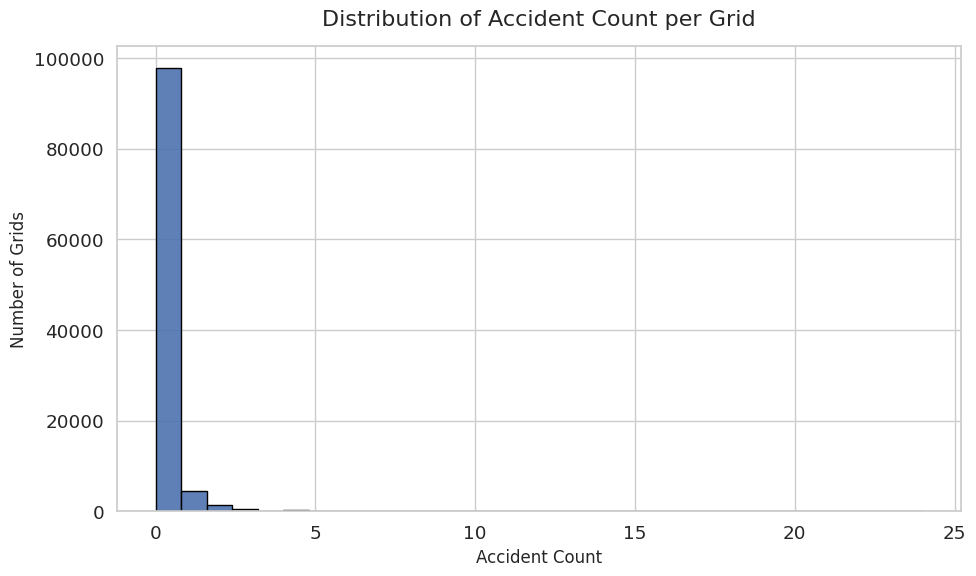

In [18]:
# 사고건수 분포 확인하기

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="acc_cnt",
    bins=30,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.9
)

plt.title("Distribution of Accident Count per Grid", fontsize=16, pad=15)
plt.xlabel("Accident Count", fontsize=12)
plt.ylabel("Number of Grids", fontsize=12)

plt.tight_layout()
plt.show()

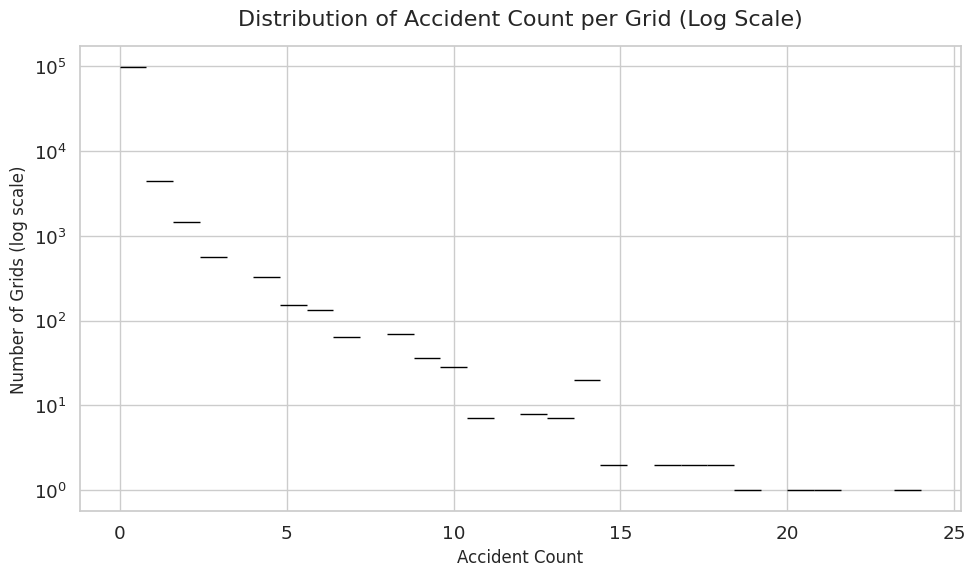

In [19]:
# 로그 스케일 버전
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="acc_cnt",
    bins=30,
    color="#DD8452",
    edgecolor="black",
    alpha=0.9,
    log_scale=(False, True)
)

plt.title("Distribution of Accident Count per Grid (Log Scale)", fontsize=16, pad=15)
plt.xlabel("Accident Count", fontsize=12)
plt.ylabel("Number of Grids (log scale)", fontsize=12)

plt.tight_layout()
plt.show()

### 교통사고 건수 분포

격자별 교통사고 건수 분포를 확인한 결과, 대부분의 격자에서는 사고가 발생하지 않았으며 일부 격자에 사고가 집중되는 비대칭 분포를 보였다.

특히 사고 건수의 중앙값과 75% 분위수가 모두 0으로 나타나, 교통사고는 도시 전반에 균등하게 발생하기보다는 특정 격자에 집중되는 특성을 가진다고 해석할 수 있다.

이러한 결과는 이후 공간 집중성 분석 및 hotspot 분석의 필요성을 보여준다.

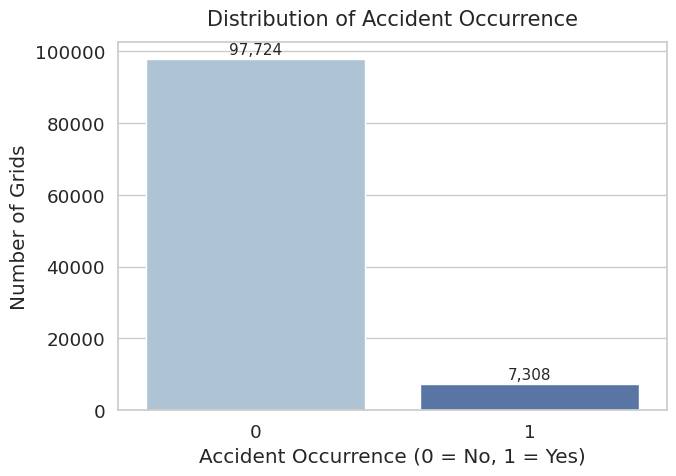

acc_binary
0    97724
1     7308
Name: count, dtype: int64
Accident occurrence rate: 0.0696


In [20]:
# 사고 발생 여부 분포
acc_binary_counts = df["acc_binary"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=acc_binary_counts.index,
    y=acc_binary_counts.values,
    palette=["#A8C5DA", "#4C72B0"]
)

for i, v in enumerate(acc_binary_counts.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", va="bottom", fontsize=11)

plt.title("Distribution of Accident Occurrence", fontsize=15, pad=12)
plt.xlabel("Accident Occurrence (0 = No, 1 = Yes)")
plt.ylabel("Number of Grids")

plt.tight_layout()
plt.show()

print(acc_binary_counts)
print(f"Accident occurrence rate: {df['acc_binary'].mean():.4f}")

## 사고 발생 여부 분포

사고 발생 여부를 기준으로 격자를 구분한 결과, 전체 격자 중 사고가 발생한 격자의 비율은 약 **6.96%**로 나타났다.

즉, 대부분의 격자는 분석 기간 동안 사고가 발생하지 않았으며, 사고는 일부 격자에서만 관측되었다. 이는 교통사고 데이터가 강한 불균형 구조를 가진다는 점을 보여준다.

이러한 특성은 단순 평균 비교만으로는 사고 위험을 충분히 설명하기 어렵고, 사고 발생 격자의 공간적·구조적 특성을 별도로 분석할 필요가 있음을 시사한다.

In [21]:
# 사고 0 격자 비율
zero_ratio = (df["acc_cnt"] == 0).mean()
nonzero_ratio = (df["acc_cnt"] > 0).mean()

print(f"Zero-accident grid ratio: {zero_ratio:.4f} ({zero_ratio*100:.2f}%)")
print(f"Accident-positive grid ratio: {nonzero_ratio:.4f} ({nonzero_ratio*100:.2f}%)")

Zero-accident grid ratio: 0.9304 (93.04%)
Accident-positive grid ratio: 0.0696 (6.96%)


무사고 격자 비율은 약 93%로 매우 높게 나타났다. 이는 교통사고가 도시 전역에 균등하게 발생하는 현상이 아니라, 제한된 일부 공간에 집중되는 현상임을 보여준다.

따라서 이후 분석에서는 단순히 전체 평균을 보는 것보다, 사고가 발생한 격자와 발생하지 않은 격자의 차이를 비교하거나, 사고 발생 격자 내부에서도 상대적으로 사고가 많은 지역을 구분해 볼 필요가 있다.

In [22]:
## 주요 연속형 변수 분포 확인 -> 일단 한 번에 진행
# 변수 그룹 정의
pop_cols = ["resident_pop", "flow_pop", "working_pop", "visit_pop", "service_pop"]
traffic_cols = ["mean_speed", "traffic_volume", "congestion_freq", "congestion_time"]
facility_cols = [
    "crosswalk_count", "bus_stop_count", "school_count",
    "kinder_count", "daycare_count", "cctv_count", "speedbump_count"
]
landuse_cols = ["is_residential", "is_commercial", "is_green", "is_road", "is_public"]

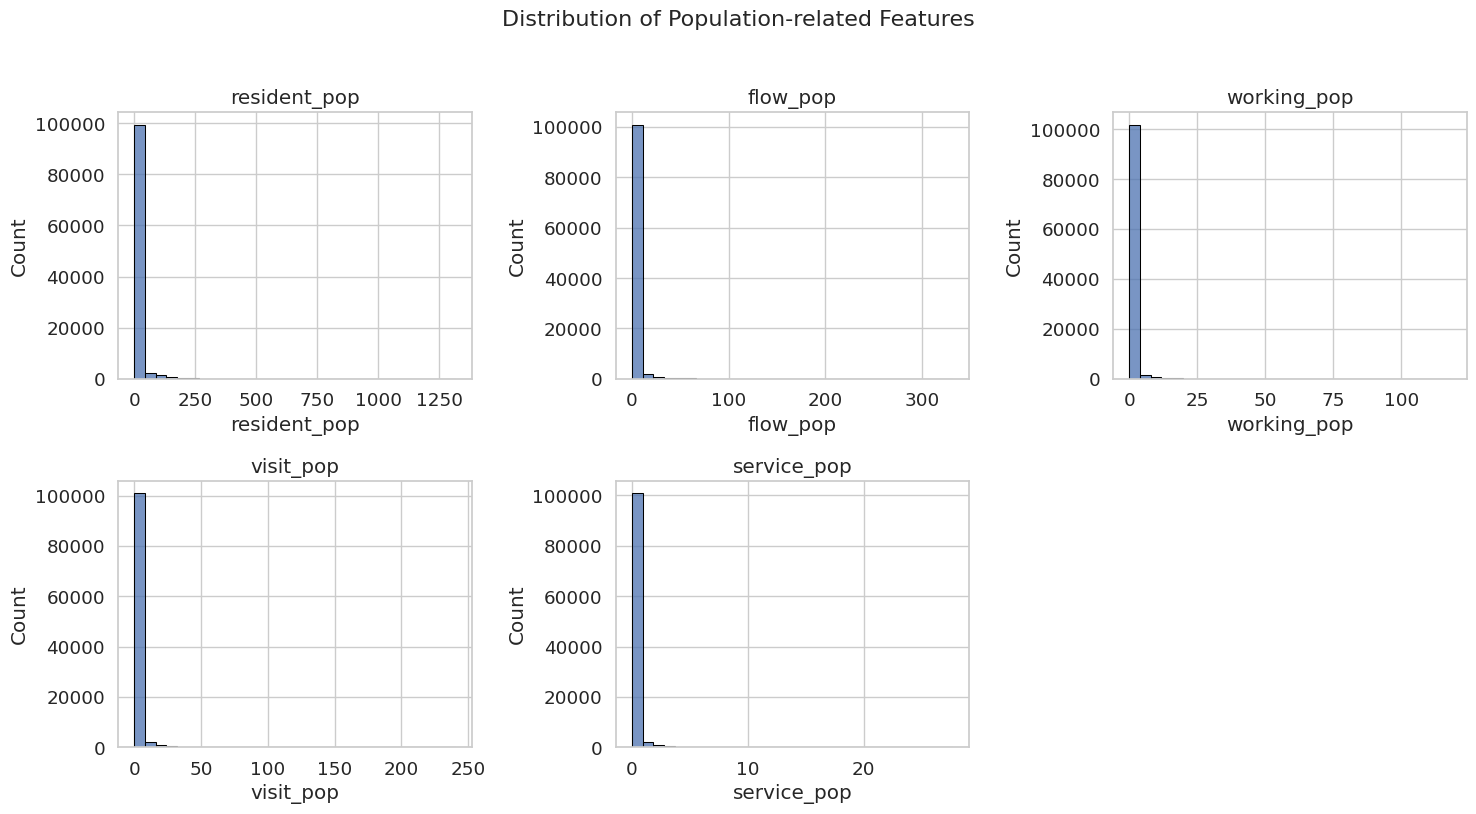

In [23]:
# 1) 인구 변수 분포
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(pop_cols):
    sns.histplot(data=df, x=col, bins=30, ax=axes[i], color="#4C72B0", edgecolor="black")
    axes[i].set_title(col)

# 마지막 빈 subplot 제거
if len(pop_cols) < len(axes):
    for j in range(len(pop_cols), len(axes)):
        fig.delaxes(axes[j])

fig.suptitle("Distribution of Population-related Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

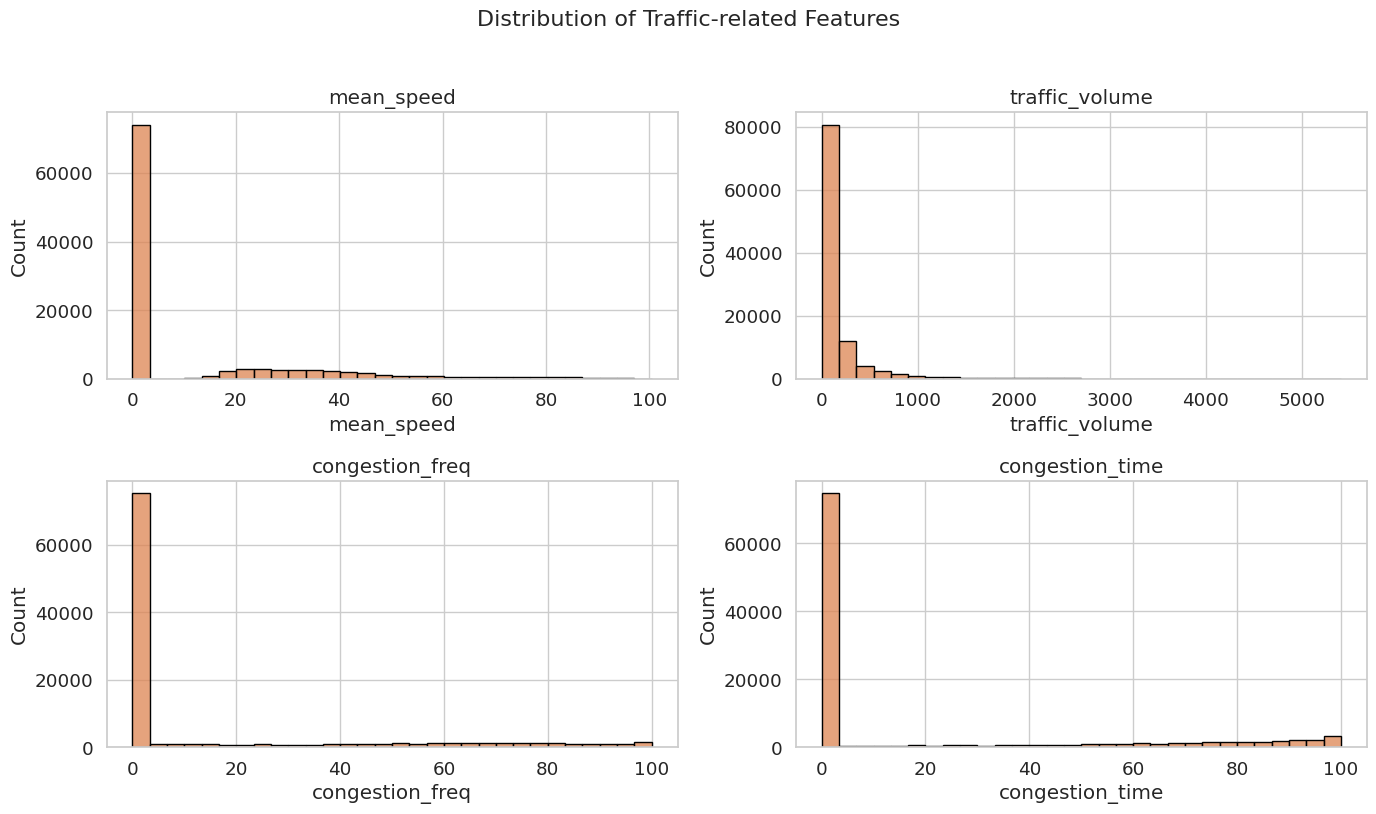

In [24]:
# 2) 교통 변수 분포
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(traffic_cols):
    sns.histplot(data=df, x=col, bins=30, ax=axes[i], color="#DD8452", edgecolor="black")
    axes[i].set_title(col)

fig.suptitle("Distribution of Traffic-related Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

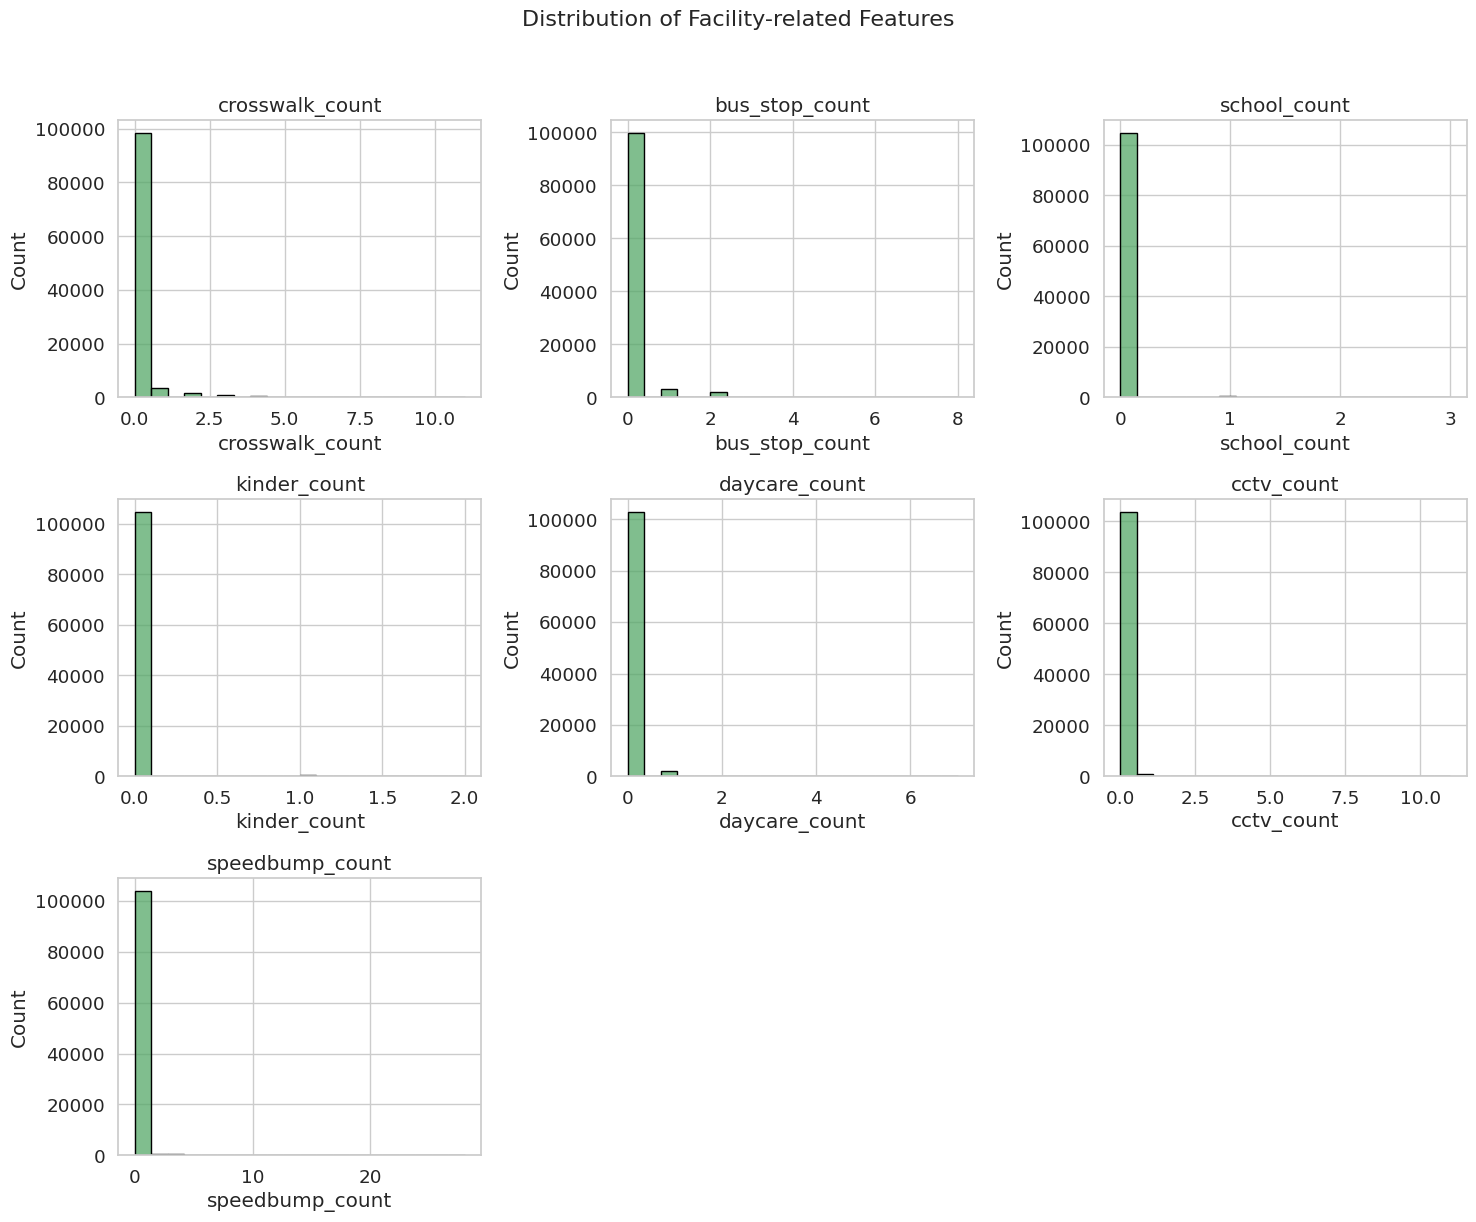

In [25]:
# 3) 시설 변수 분포
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(facility_cols):
    sns.histplot(data=df, x=col, bins=20, ax=axes[i], color="#55A868", edgecolor="black")
    axes[i].set_title(col)

# 남는 subplot 제거
for j in range(len(facility_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribution of Facility-related Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 주요 설명변수 분포

인구, 교통, 시설 관련 변수의 분포를 확인한 결과, 대부분의 변수에서 0 또는 매우 작은 값이 집중되어 있고 일부 격자에서만 큰 값이 나타나는 오른쪽 꼬리 분포가 확인되었다.

이는 격자 단위 도시 데이터의 특성을 잘 보여준다. 즉, 모든 격자가 동일한 기능을 수행하는 것이 아니라, 일부 격자에 사람의 이동, 차량 흐름, 생활 편의시설, 보행 시설 등이 집중되어 있다는 의미이다.

특히 유동인구, 방문인구, 교통량과 같은 변수는 일부 격자에서 높은 값을 보이며, 이러한 활동 밀집 지역이 사고 위험과 어떤 관련을 가지는지 추가적으로 살펴볼 필요가 있다.

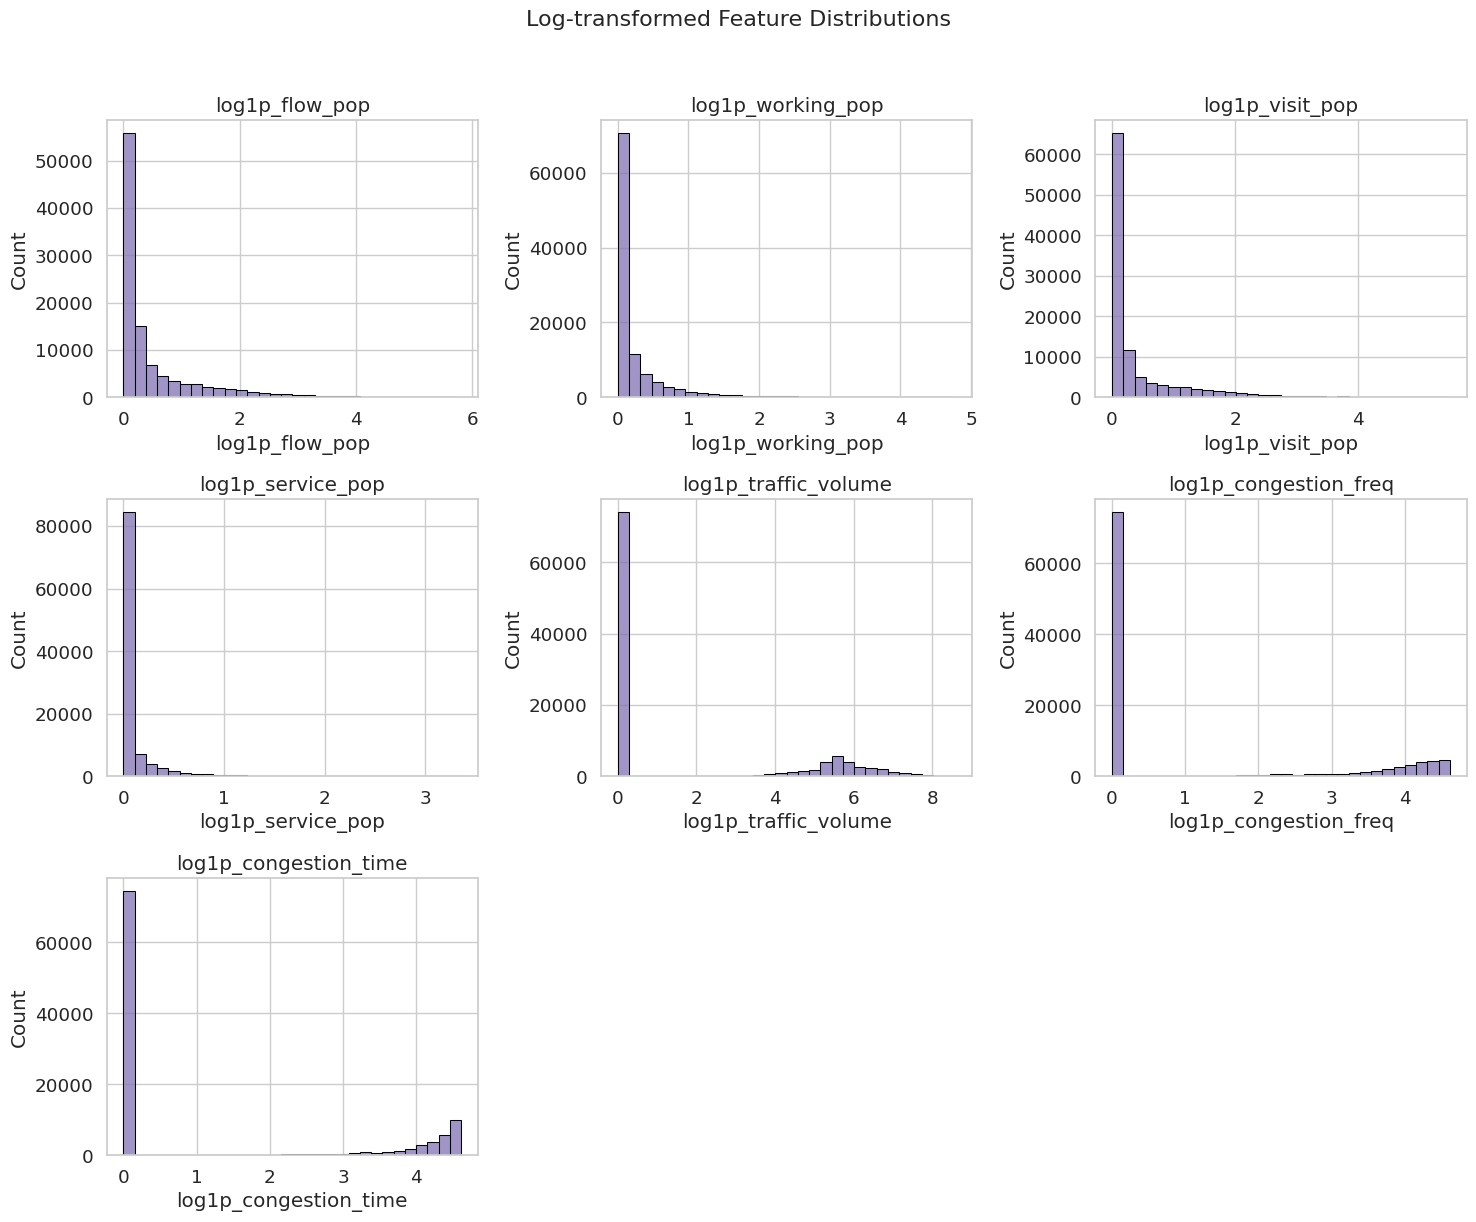

In [26]:
# 로그 변환 분포 확인
log_cols = ["flow_pop", "working_pop", "visit_pop", "service_pop",
            "traffic_volume", "congestion_freq", "congestion_time"]

log_df = df[log_cols].copy()

for col in log_cols:
    log_df[f"log1p_{col}"] = np.log1p(log_df[col])

plot_cols = [f"log1p_{col}" for col in log_cols]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.histplot(data=log_df, x=col, bins=30, ax=axes[i], color="#8172B3", edgecolor="black")
    axes[i].set_title(col)

for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Log-transformed Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

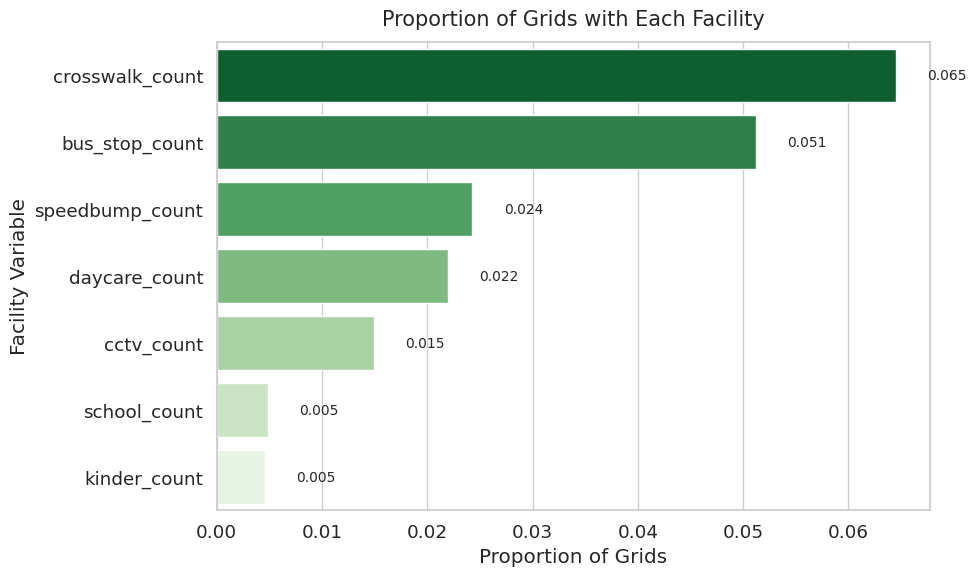

crosswalk_count    0.064514
bus_stop_count     0.051213
speedbump_count    0.024278
daycare_count      0.021936
cctv_count         0.014900
school_count       0.004856
kinder_count       0.004551
dtype: float64

In [27]:
# 4) 시설 보유 격자 비율
facility_presence = pd.Series({
    col: (df[col] > 0).mean()
    for col in facility_cols
}).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=facility_presence.values,
    y=facility_presence.index,
    palette="Greens_r"
)

for i, v in enumerate(facility_presence.values):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=10)

plt.title("Proportion of Grids with Each Facility", fontsize=15, pad=12)
plt.xlabel("Proportion of Grids")
plt.ylabel("Facility Variable")

plt.tight_layout()
plt.show()

facility_presence

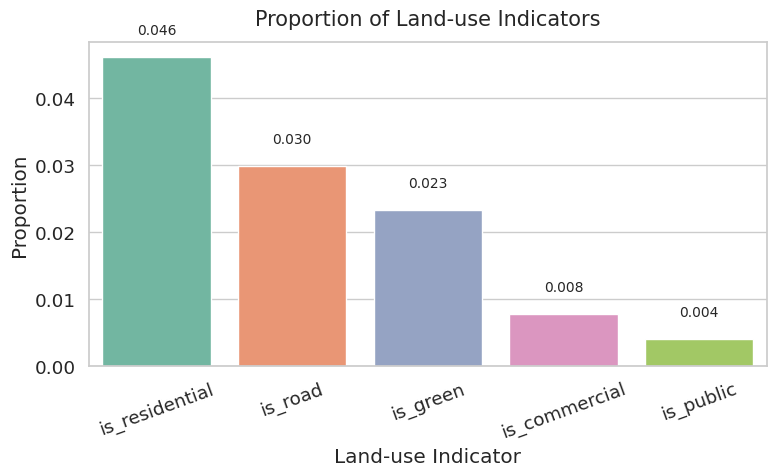

is_residential    0.046138
is_road           0.029886
is_green          0.023307
is_commercial     0.007826
is_public         0.004056
dtype: float64

In [28]:
# 5) 토지이용 더미 변수 비율
landuse_ratio = df[landuse_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=landuse_ratio.index,
    y=landuse_ratio.values,
    palette="Set2"
)

for i, v in enumerate(landuse_ratio.values):
    ax.text(i, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=10)

plt.title("Proportion of Land-use Indicators", fontsize=15, pad=12)
plt.xlabel("Land-use Indicator")
plt.ylabel("Proportion")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

landuse_ratio

In [29]:
# 6) 도시별 사고 요약
city_summary = df.groupby("city").agg(
    grid_count=("gid", "count"),
    total_acc=("acc_cnt", "sum"),
    mean_acc=("acc_cnt", "mean"),
    accident_rate=("acc_binary", "mean")
).reset_index()

city_summary = city_summary.sort_values("accident_rate", ascending=False)
city_summary

,city,grid_count,total_acc,mean_acc,accident_rate
3,서울특별시 송파구,3899,2968,0.761221,0.290331
0,경기도 성남시,15923,4146,0.260378,0.124600
1,경기도 하남시,10586,2043,0.192991,0.092764
2,경기도 화성시,74624,5106,0.068423,0.043016


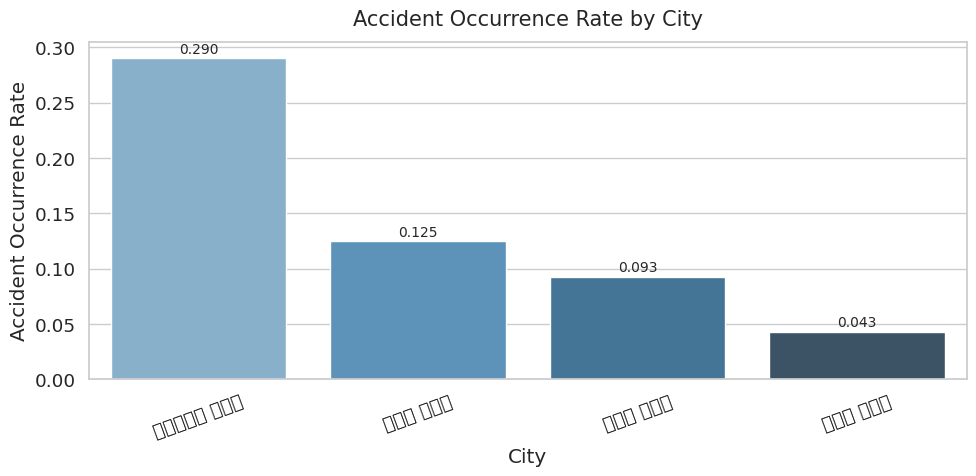

In [30]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=city_summary,
    x="city",
    y="accident_rate",
    palette="Blues_d"
)

for i, v in enumerate(city_summary["accident_rate"]):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", va="bottom", fontsize=10)

plt.title("Accident Occurrence Rate by City", fontsize=15, pad=12)
plt.xlabel("City")
plt.ylabel("Accident Occurrence Rate")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

도시별 사고 발생 비율을 비교한 결과, 사고 발생 수준에는 도시 간 차이가 존재하는 것으로 나타났다.

이는 각 도시의 인구 구조, 도로 체계, 생활권 밀도, 교통 흐름 등이 서로 다르기 때문일 가능성이 있으며, 이후 구조적 특성 분석에서 도시별 차이를 고려해 볼 필요가 있음을 보여준다.

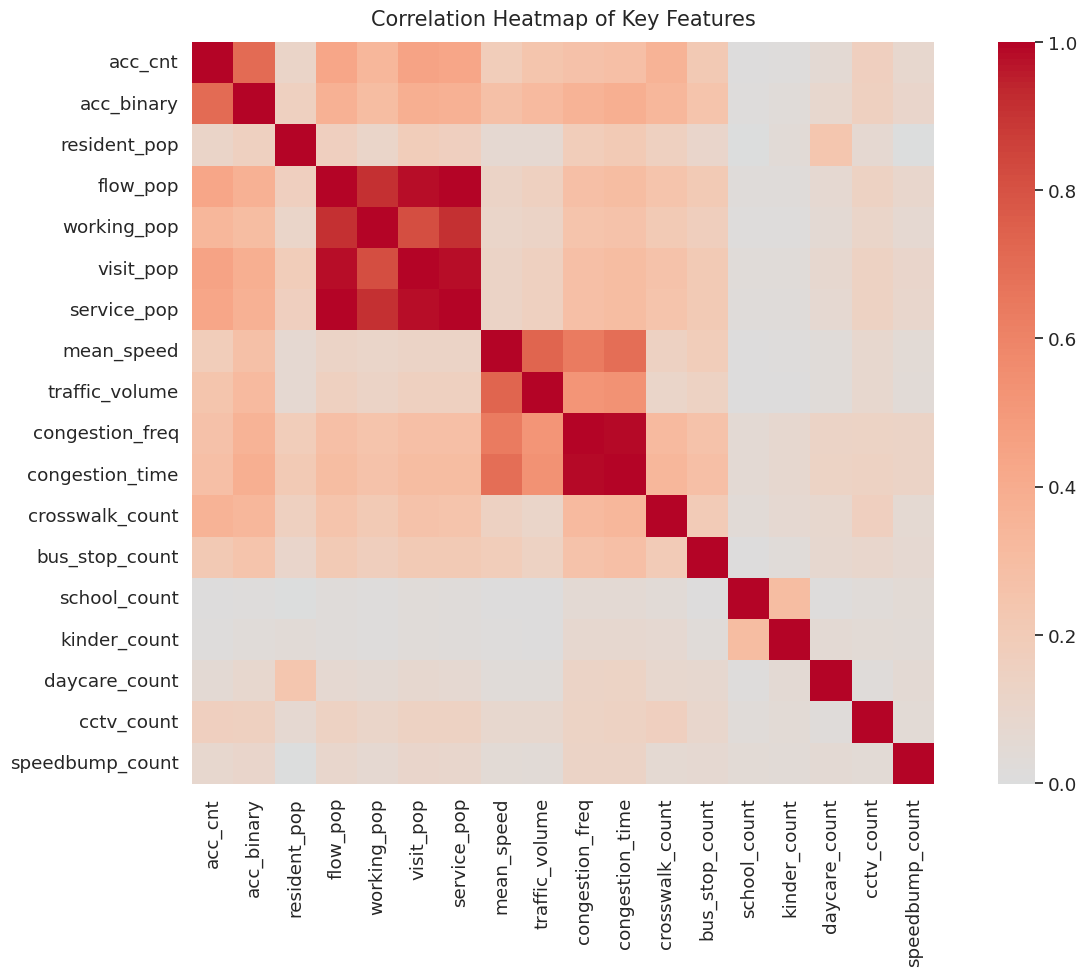

In [31]:
# 주요 변수 상관관계
key_cols = [
    "acc_cnt", "acc_binary",
    "resident_pop", "flow_pop", "working_pop", "visit_pop", "service_pop",
    "mean_speed", "traffic_volume", "congestion_freq", "congestion_time",
    "crosswalk_count", "bus_stop_count", "school_count", "kinder_count",
    "daycare_count", "cctv_count", "speedbump_count"
]

corr_key = df[key_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_key,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True
)

plt.title("Correlation Heatmap of Key Features", fontsize=15, pad=12)
plt.tight_layout()
plt.show()

In [32]:
# 사고건수와의 상관만 따로 보기
corr_with_acc = corr_key["acc_cnt"].sort_values(ascending=False)
corr_with_acc

acc_cnt            1.000000
acc_binary         0.708299
visit_pop          0.448617
flow_pop           0.430289
service_pop        0.430038
crosswalk_count    0.360992
working_pop        0.337600
congestion_time    0.287307
congestion_freq    0.265842
traffic_volume     0.242368
bus_stop_count     0.216346
mean_speed         0.186257
cctv_count         0.159936
resident_pop       0.117965
speedbump_count    0.083919
daycare_count      0.055436
kinder_count       0.016372
school_count       0.003432
Name: acc_cnt, dtype: float64

## 변수 간 상관 구조

- 주요 변수의 상관관계를 확인한 결과, 유동인구·방문인구·서비스인구 등 도시 활동 밀도를 나타내는 변수들 사이에는 비교적 높은 양의 상관이 나타났다.

- 또한 교통량, 혼잡빈도, 혼잡시간 역시 서로 일정 수준의 연관성을 보였으며, 이는 사람과 차량의 이동이 집중되는 공간이 공통된 특성을 가질 가능성을 보여준다.

- 한편 사고 건수와 개별 변수 간 단순 상관은 크지 않을 수 있으나, 이는 교통사고가 단일 변수보다는 여러 구조적 요인이 결합된 결과일 가능성을 시사한다.

In [33]:
# 90% 분위수 기준으로 잡아도 임계값이 0 
# No Accident vs Accident 기준으로 나누기

# 사고 발생 격자 vs 무사고 격자 비교
df["acc_group"] = np.where(df["acc_cnt"] == 0, "No Accident", "Accident")

compare_cols = [
    "flow_pop", "visit_pop", "traffic_volume", "congestion_freq",
    "crosswalk_count", "bus_stop_count", "cctv_count", "speedbump_count"
]

group_mean = df.groupby("acc_group")[compare_cols].mean().T
group_mean

acc_group,Accident,No Accident
flow_pop,14.297482,1.236413
visit_pop,10.339621,0.831946
traffic_volume,609.476128,114.930894
congestion_freq,53.637809,12.736028
crosswalk_count,0.916119,0.075171
bus_stop_count,0.433224,0.051758
cctv_count,0.159004,0.013272
speedbump_count,0.205118,0.036398


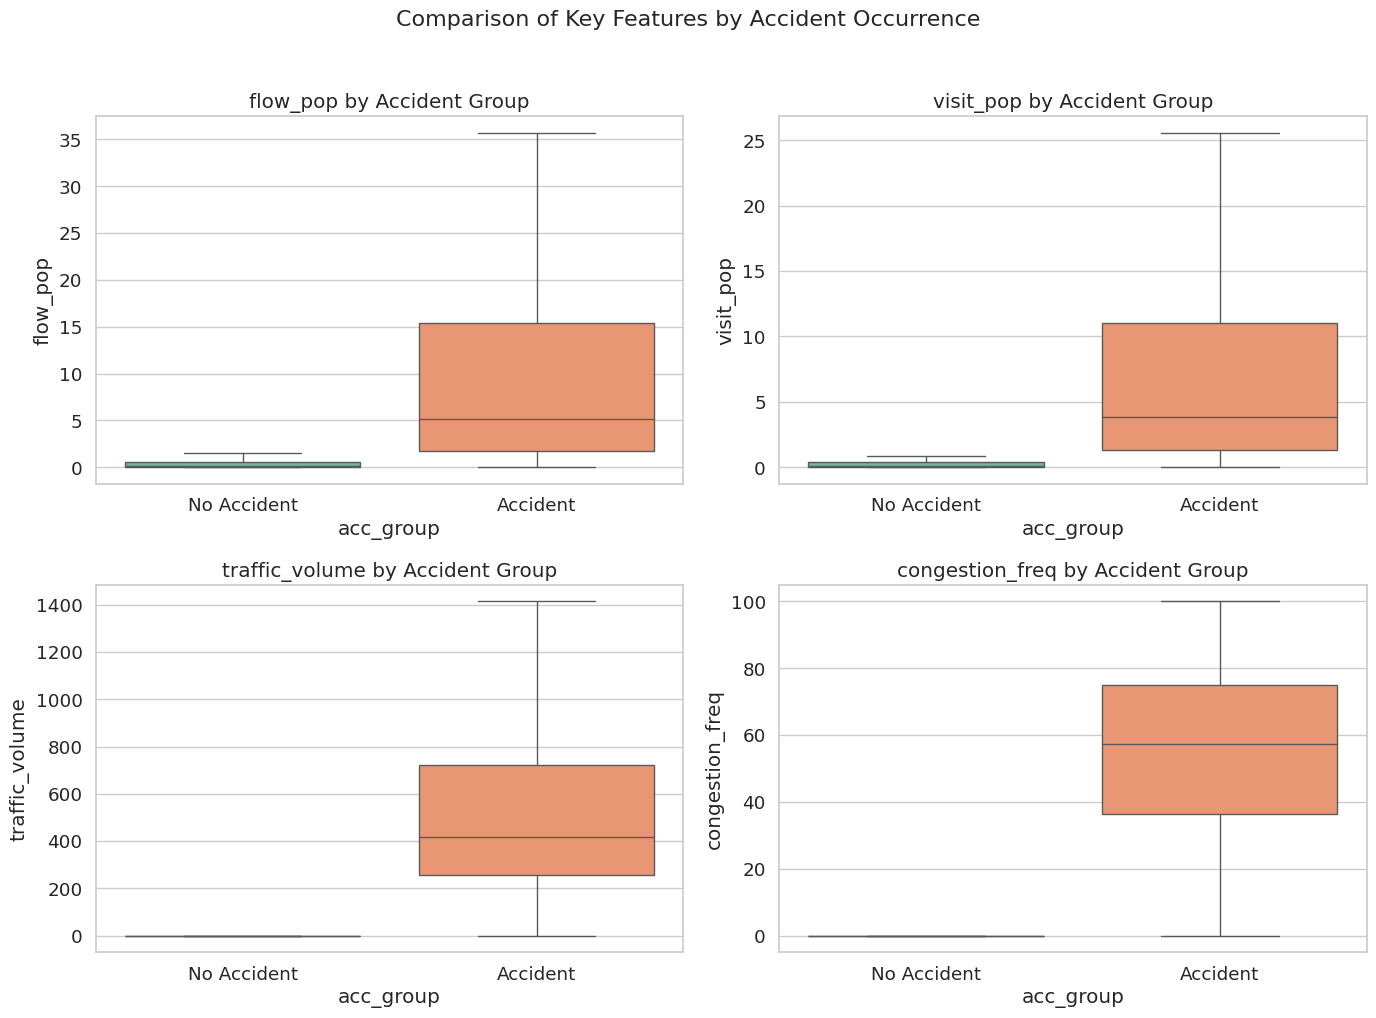

In [34]:
plot_compare_cols = ["flow_pop", "visit_pop", "traffic_volume", "congestion_freq"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(plot_compare_cols):
    sns.boxplot(
        data=df,
        x="acc_group",
        y=col,
        ax=axes[i],
        palette="Set2",
        showfliers=False
    )
    axes[i].set_title(f"{col} by Accident Group")

fig.suptitle("Comparison of Key Features by Accident Occurrence", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 사고 발생 격자와 무사고 격자의 구조적 차이

사고 발생 격자와 무사고 격자의 주요 변수 평균을 비교한 결과, 두 집단 간에는 뚜렷한 차이가 나타났다.

특히 사고 발생 격자에서는 유동인구(flow_pop)와 방문인구(visit_pop)가 무사고 격자 대비 약 10배 이상 높게 나타났으며, 교통량(traffic_volume)과 혼잡빈도(congestion_freq) 역시 약 4~5배 수준으로 높게 나타났다.

또한 횡단보도(crosswalk_count), 버스정류장(bus_stop_count)과 같은 보행 및 대중교통 관련 시설 역시 사고 발생 격자에서 더 많이 분포하는 것으로 나타났다.

이러한 결과는 교통사고가 단순히 임의적으로 발생하는 현상이 아니라, 사람과 차량의 이동이 집중되는 도시 활동 밀집 지역에서 더 높은 확률로 발생할 가능성을 보여준다.

따라서 이후 분석에서는 이러한 공간적 특성이 실제로 특정 지역에 군집되어 나타나는지 확인하기 위해 공간 집중성 분석 및 hotspot 분석을 수행한다.

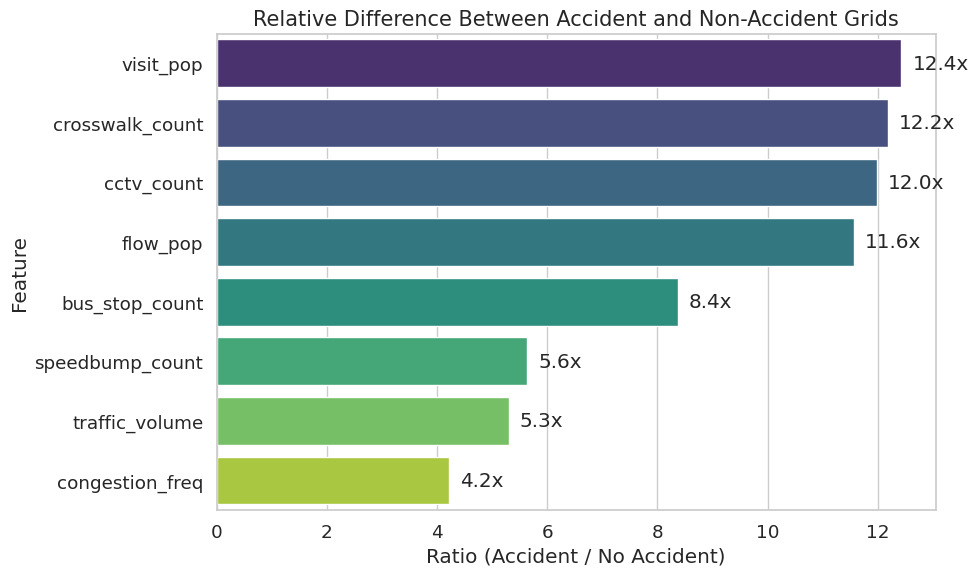

In [35]:
# 비율 비교 bar 차트
compare_ratio = (group_mean["Accident"] / group_mean["No Accident"]).sort_values(ascending=False)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=compare_ratio.values,
    y=compare_ratio.index,
    palette="viridis"
)

for i, v in enumerate(compare_ratio.values):
    ax.text(v + 0.2, i, f"{v:.1f}x", va="center")

plt.title("Relative Difference Between Accident and Non-Accident Grids", fontsize=15)
plt.xlabel("Ratio (Accident / No Accident)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## EDA 요약

본 탐색적 분석을 통해 다음과 같은 특징을 확인할 수 있었다.

1. 격자 단위 교통사고 분포는 매우 불균형하며 대부분의 격자에서는 사고가 발생하지 않았다.
2. 사고는 도시 전반에 균등하게 발생하기보다는 특정 격자에 집중되는 경향을 보였다.
3. 사고 발생 격자는 무사고 격자 대비 유동인구, 방문인구, 교통량, 혼잡도 등이 크게 높은 경향을 보였다.
4. 또한 횡단보도, 버스정류장 등 보행 및 교통 시설이 더 많이 분포하는 특징이 나타났다.

이러한 결과는 교통사고가 도시 내 활동 밀도와 교통 구조와 밀접하게 관련되어 있을 가능성을 시사한다.

다음 단계에서는 교통사고가 실제로 공간적으로 군집되어 나타나는지 확인하기 위해 공간 자기상관 분석과 hotspot 분석을 수행한다.